[*********************100%***********************]  1 of 1 completed


Toplam veri boyutu: 2516
Train X boyutu: torch.Size([1996, 20, 1])
Test X boyutu:  torch.Size([500, 20, 1])
--- LSTM Eğitimi Başlıyor ---
Epoch: 20, Loss: 0.04538
Epoch: 40, Loss: 0.00301
Epoch: 60, Loss: 0.00155
Epoch: 80, Loss: 0.00106
Epoch: 100, Loss: 0.00085
Eğitim Süresi: 4.03 saniye

--- GRU Eğitimi Başlıyor ---
Epoch: 20, Loss: 0.01230
Epoch: 40, Loss: 0.00200
Epoch: 60, Loss: 0.00077
Epoch: 80, Loss: 0.00048
Epoch: 100, Loss: 0.00039
Eğitim Süresi: 7.84 saniye



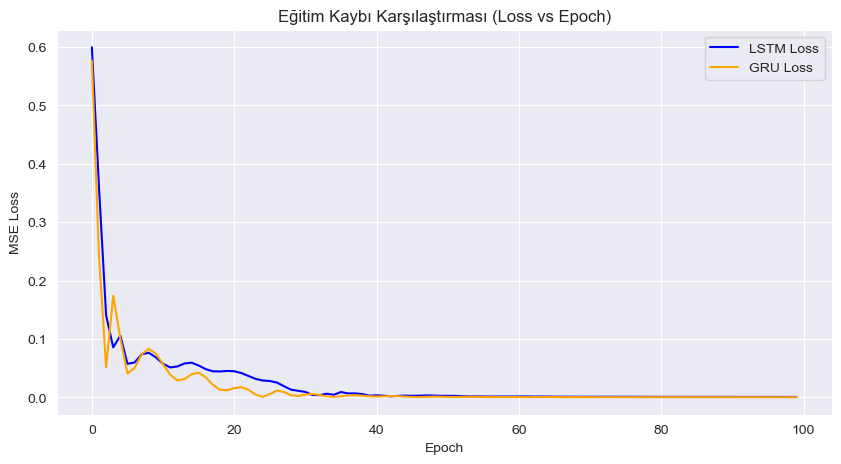

LSTM Test MSE: 4598.65
GRU Test MSE:  310.72


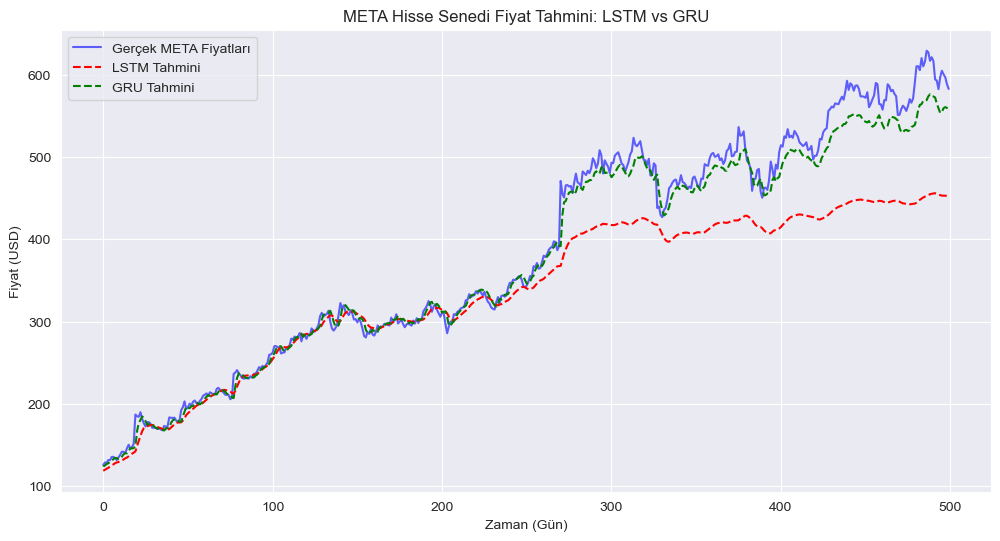

In [4]:
import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn


df = yf.download("META", start="2015-01-01", end="2025-01-01")

data = df["Close"].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_data = scaler.fit_transform(data)

print(f"Toplam veri boyutu: {len(scaled_data)}")


def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

lookback = 20
X, y = create_sequences(scaled_data, lookback)

train_size = int(len(X) * 0.8)

X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

X_train = torch.from_numpy(X_train).type(torch.Tensor)
y_train = torch.from_numpy(y_train).type(torch.Tensor)
X_test = torch.from_numpy(X_test).type(torch.Tensor)
y_test = torch.from_numpy(y_test).type(torch.Tensor)

print(f"Train X boyutu: {X_train.shape}")
print(f"Test X boyutu:  {X_test.shape}")


class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :]) 
        return out

class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(GRUModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        out, _ = self.gru(x, h0.detach())
        out = self.fc(out[:, -1, :])
        return out


input_dim = 1
hidden_dim = 32
num_layers = 2
output_dim = 1
num_epochs = 100

lstm_model = LSTMModel(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim, num_layers=num_layers)
gru_model = GRUModel(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim, num_layers=num_layers)

criterion = nn.MSELoss()
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.01)
gru_optimizer = torch.optim.Adam(gru_model.parameters(), lr=0.01)

def train_model(model, optimizer, name):
    start_time = time.time()
    train_losses = []
    
    print(f"--- {name} Eğitimi Başlıyor ---")
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch: {epoch + 1}, Loss: {loss.item():.5f}")
            
    print(f"Eğitim Süresi: {time.time() - start_time:.2f} saniye\n")
    return train_losses

lstm_losses = train_model(lstm_model, lstm_optimizer, "LSTM")
gru_losses = train_model(gru_model, gru_optimizer, "GRU")

# ==========================================
# 5. EĞİTİM KAYBI (EPOCH - LOSS) GRAFİĞİ
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(lstm_losses, label="LSTM Loss", color="blue")
plt.plot(gru_losses, label="GRU Loss", color="orange")
plt.title("Eğitim Kaybı Karşılaştırması (Loss vs Epoch)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# 6. TAHMİN, MSE DEĞERLENDİRME VE FİYAT GRAFİĞİ
# ==========================================
lstm_model.eval()
gru_model.eval()

with torch.no_grad():
    lstm_predictions = lstm_model(X_test)
    gru_predictions = gru_model(X_test)

lstm_pred_original = scaler.inverse_transform(lstm_predictions.numpy())
gru_pred_original = scaler.inverse_transform(gru_predictions.numpy())
y_test_original = scaler.inverse_transform(y_test.numpy())

lstm_mse = mean_squared_error(y_test_original, lstm_pred_original)
gru_mse = mean_squared_error(y_test_original, gru_pred_original)

print(f"LSTM Test MSE: {lstm_mse:.2f}")
print(f"GRU Test MSE:  {gru_mse:.2f}")

plt.figure(figsize=(12, 6))
plt.plot(y_test_original, label='Gerçek META Fiyatları', color='blue', alpha=0.6)
plt.plot(lstm_pred_original, label='LSTM Tahmini', color='red', linestyle='dashed')
plt.plot(gru_pred_original, label='GRU Tahmini', color='green', linestyle='dashed')

plt.title('META Hisse Senedi Fiyat Tahmini: LSTM vs GRU')
plt.xlabel('Zaman (Gün)')
plt.ylabel('Fiyat (USD)')
plt.legend()
plt.grid(True)
plt.show()